# Gram-Schmidt — Building Orthonormal Bases

Gram-Schmidt takes any independent set and straightens it into an **orthonormal** one, vector by
vector: subtract off the part that overlaps everything chosen so far, then normalise.

$$e_k = \frac{v_k - \sum_{j<k}\langle e_j,v_k\rangle\,e_j}{\big\|\,v_k - \sum_{j<k}\langle e_j,v_k\rangle\,e_j\,\big\|}.$$

It is the constructive engine behind the orthogonal bases of the Hilbert-space notebook: applied to
vectors it gives the **QR decomposition**; applied to the **monomials** $1,x,x^2,\dots$ it *generates
the Legendre polynomials*; and the complex-exponential basis $e^{jx}$ is already orthogonal, so it
does nothing there. Engine: `griffiths.hilbert.gram_schmidt`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math
from griffiths import hilbert as hb

sp.init_printing(use_latex="mathjax")
x = sp.Symbol("x", real=True)
print("gram_schmidt ready")

gram_schmidt ready


## 1 — Vectors: from skewed to orthonormal

Three independent (but non-perpendicular) vectors, straightened by Gram-Schmidt into an orthonormal
set. The result satisfies $Q^{\mathsf H}Q = I$.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Q^H Q == I ? True


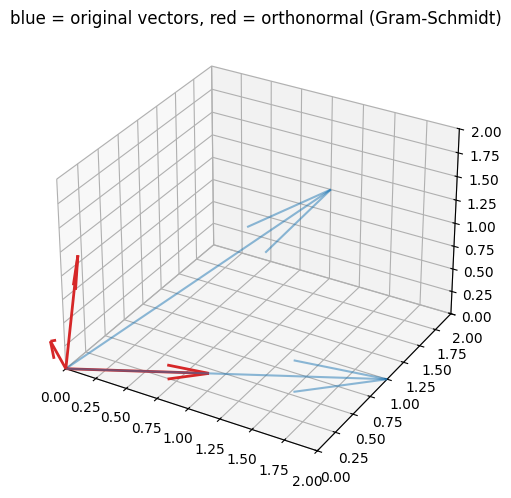

In [2]:
vecs = [[2, 1, 0], [1, 2, 1], [0, 1, 2]]
Q = hb.gram_schmidt_vectors(vecs)
for i, q in enumerate(Q):
    display(Math(rf"e_{i+1} = " + sp.latex(q.T)))
Qm = sp.Matrix.hstack(*Q)
print("Q^H Q == I ?", sp.simplify(Qm.H * Qm) == sp.eye(3))

# show the first two original vs orthonormalized vectors in the plane they span
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection="3d")
o = np.zeros(3)
for v, c, l in [(np.array(vecs[0], float), "C0", "v1"), (np.array(vecs[1], float), "C0", "v2")]:
    ax.quiver(*o, *v, color=c, alpha=0.5)
for q, l in zip(Q, ["e1", "e2", "e3"]):
    qn = np.array(q.T.tolist()[0], float)
    ax.quiver(*o, *qn, color="C3", lw=2)
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_zlim(0, 2)
ax.set_title("blue = original vectors, red = orthonormal (Gram-Schmidt)")
plt.tight_layout(); plt.show()

## 2 — Gram-Schmidt *is* the QR decomposition

Stack the orthonormal vectors as the columns of $Q$; the overlaps you subtracted off are the entries
of an upper-triangular $R$, and $A = QR$. (numpy's `qr` does exactly this, more stably.)

In [3]:
A = np.array(vecs, float).T
Qn, Rn = np.linalg.qr(A)
print("A = Q R reconstruction error:", np.linalg.norm(A - Qn @ Rn))
print("Q^T Q == I ?", np.allclose(Qn.T @ Qn, np.eye(3)))
print("R upper-triangular ?", np.allclose(Rn, np.triu(Rn)))

A = Q R reconstruction error: 6.415846369550005e-16
Q^T Q == I ? True
R upper-triangular ? True


## 3 — The gem: Gram-Schmidt on $1,x,x^2,\dots$ gives Legendre

Orthogonalise the monomials under $\langle f,g\rangle=\int_{-1}^{1}fg\,dx$ and out come the **Legendre
polynomials** (here in their monic-ish form; rescaling to $P_\ell(1)=1$ gives the textbook ones). The
basis the sphere problem needed is *built*, not assumed.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

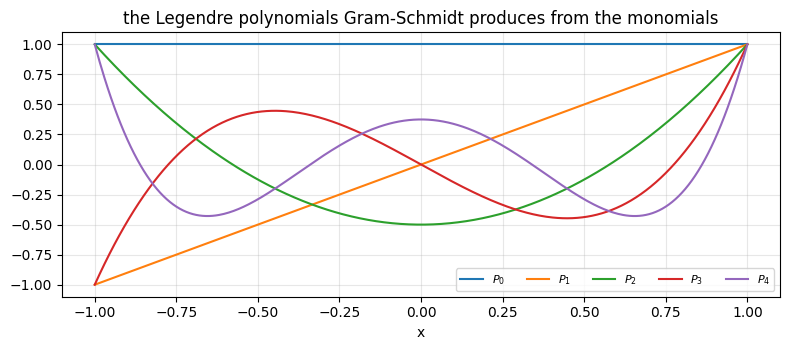

In [4]:
gs = hb.gram_schmidt([1, x, x**2, x**3, x**4], x, -1, 1, normalize=False)
for l, g in enumerate(gs):
    Pl = sp.legendre(l, x)
    display(Math(rf"\text{{GS}}_{l} = " + sp.latex(sp.expand(g))
                 + rf"\quad=\quad " + sp.latex(sp.nsimplify(sp.simplify(g/Pl)))
                 + rf"\,P_{l}(x)"))

xs = np.linspace(-1, 1, 400)
plt.figure(figsize=(8, 3.6))
for l, g in enumerate(gs):
    f = sp.lambdify(x, sp.legendre(l, x), "numpy")
    plt.plot(xs, f(xs)*np.ones_like(xs), label=f"$P_{l}$")
plt.title("the Legendre polynomials Gram-Schmidt produces from the monomials")
plt.xlabel("x"); plt.legend(ncol=5, fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4 — The complex exponential $e^{jx}$ is already orthogonal

Euler: $e^{jx}=\cos x + j\sin x$ — the "real feelings" are the cosine, the imaginary the sine. The
Fourier basis $\{e^{jnx}\}$ on $[-\pi,\pi]$ is *already* orthogonal,
$\langle e^{jmx},e^{jnx}\rangle=\int_{-\pi}^{\pi}e^{-jmx}e^{jnx}\,dx=2\pi\delta_{mn}$, so Gram-Schmidt
has nothing to do — which is exactly why the FFT works in one shot.

<IPython.core.display.Math object>

orthogonal for m!=n: True | norm^2 at m=n=1: 2*pi


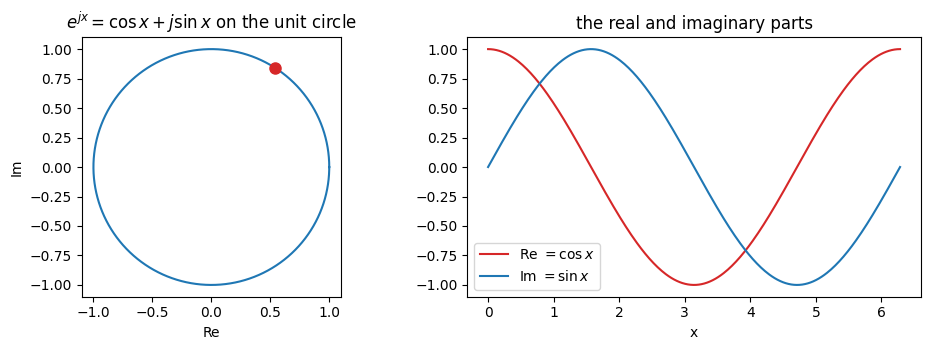

In [5]:
m, n = sp.symbols("m n", integer=True)
ip = sp.integrate(sp.exp(-sp.I*m*x)*sp.exp(sp.I*n*x), (x, -sp.pi, sp.pi))
display(Math(r"\langle e^{jmx}, e^{jnx}\rangle = " + sp.latex(ip)
             + r"\quad(=2\pi \text{ if } m=n,\ 0 \text{ else})"))
print("orthogonal for m!=n:", sp.simplify(ip.subs({m: 1, n: 2})) == 0,
      "| norm^2 at m=n=1:", sp.simplify(ip.subs({m: 1, n: 1})))

# Euler on the unit circle
th = np.linspace(0, 2*np.pi, 300)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(np.cos(th), np.sin(th), "C0"); ax[0].plot(np.cos(1.0), np.sin(1.0), "C3o", ms=8)
ax[0].set_aspect("equal"); ax[0].set_title("$e^{jx}=\\cos x + j\\sin x$ on the unit circle")
ax[0].set_xlabel("Re"); ax[0].set_ylabel("Im")
ax[1].plot(th, np.cos(th), "C3", label="Re $= \\cos x$"); ax[1].plot(th, np.sin(th), "C0", label="Im $= \\sin x$")
ax[1].set_xlabel("x"); ax[1].legend(); ax[1].set_title("the real and imaginary parts")
plt.tight_layout(); plt.show()

## 5 — Why it matters

- **Orthonormal bases are made, not given.** Gram-Schmidt is the constructive proof behind the
  Hilbert-space picture (`hilbert_space_orthogonal_bases.ipynb`): hand it the monomials and the
  Legendre basis appears; hand it any geometry's natural functions and you get that geometry's basis.
- **QR is Gram-Schmidt.** $A=QR$ powers least-squares fitting, eigenvalue iteration (the QR algorithm),
  and stable linear solves — the workhorse of numerical linear algebra.
- **$e^{jx}$ is the free lunch.** The Fourier/phasor basis is born orthogonal, so no orthogonalisation
  is needed — which is precisely why the FFT, and the whole dispersion-GS pipeline that lives in the
  Fourier domain, is so efficient.
- **Numerical caveat.** Classical Gram-Schmidt loses orthogonality to rounding; *modified* Gram-Schmidt
  (subtract projections one at a time, as the loop here does) or Householder QR (numpy's `qr`) is what
  you use in practice.

Engine: `griffiths.hilbert.gram_schmidt` / `gram_schmidt_vectors`, verified to reproduce Legendre and
to give $Q^{\mathsf H}Q=I$.